# SIP Week 5: CTC Reliability and Diagnostics

In this notebook, we follow the Week 5 hands-on tasks introduced in the lecture.

## Tasks
- Task 1: Train a baseline CNN + BiLSTM + CTC model
- Task 2: Run multiple seeds and measure variability
- Task 3: Compute confidence intervals
- Task 4: Analyze entropy and alignment
- Task 5: Perform error analysis

## Goal
The goal is not only to run a model, but to understand its reliability and behavior.

## Reproducibility and Logging

In this notebook, we try to make experiments reproducible.

We will:
- fix random seeds
- log important settings
- keep outputs organized
- report results clearly

This is important because reliability means not only good accuracy, but also stability and reproducibility.

In [1]:
# ALWAYS RUN THIS FIRST
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Reproducibility helpers (safe version)

def set_seed(seed: int = 42):
    import random
    import numpy as np
    import torch

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


SEED = 42
set_seed(SEED)
print("Seed set to:", SEED)

Seed set to: 42


In [3]:
from pathlib import Path

# Output directories

ROOT = Path("./week5_outputs")
DIRS = {
    "root": ROOT,
    "plots": ROOT / "plots",
    "logs": ROOT / "logs",
    "models": ROOT / "models",
    "results": ROOT / "results",
}

for d in DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

print("Created directories:")
for name, d in DIRS.items():
    print(f"{name}: {d}")

Created directories:
root: week5_outputs
plots: week5_outputs/plots
logs: week5_outputs/logs
models: week5_outputs/models
results: week5_outputs/results


In [4]:
import json

# Simple experiment config

config = {
    "seed": SEED,
    "sample_rate": 16000,
    "n_mels": 64,
    "batch_size": 8,
    "hidden_dim": 64,
    "num_lstm_layers": 1,
    "dropout": 0.1,
    "learning_rate": 1e-3,
    "num_epochs": 5,
    "blank_id": 0,
}

config_path = DIRS["logs"] / "config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print("Saved config to:", config_path)
config

Saved config to: week5_outputs/logs/config.json


{'seed': 42,
 'sample_rate': 16000,
 'n_mels': 64,
 'batch_size': 8,
 'hidden_dim': 64,
 'num_lstm_layers': 1,
 'dropout': 0.1,
 'learning_rate': 0.001,
 'num_epochs': 5,
 'blank_id': 0}

## Task 1: Load a Small Speech Dataset

We start with the YESNO dataset in torchaudio.

This dataset is small and suitable for a laptop-based CTC experiment.

At this stage, we only check:
- how many samples exist
- what one sample looks like
- what the labels look like

In [5]:
from pathlib import Path

data_root = Path("../data")
data_root.mkdir(parents=True, exist_ok=True)

print("Data directory:", data_root.resolve())

Data directory: /Users/tmatsui/Dropbox/SLAI/SIP/data


In [6]:
import torchaudio

yesno_dataset = torchaudio.datasets.YESNO(
    root=str(data_root),
    download=True
)

print("Number of utterances:", len(yesno_dataset))

Number of utterances: 60


## Inspect One Example

Now we inspect one sample from the dataset.

We check:
- waveform shape
- sample rate
- label sequence
- duration

In [7]:
waveform, sample_rate, labels = yesno_dataset[0]

print("Waveform shape:", waveform.shape)
print("Sample rate:", sample_rate)
print("Labels:", labels)
print("Duration (sec):", waveform.shape[1] / sample_rate)

Waveform shape: torch.Size([1, 50800])
Sample rate: 8000
Labels: [0, 0, 0, 0, 1, 1, 1, 1]
Duration (sec): 6.35


## Visualize Waveform

We plot the waveform of one sample.

This helps us understand:
- time structure of speech
- signal variation

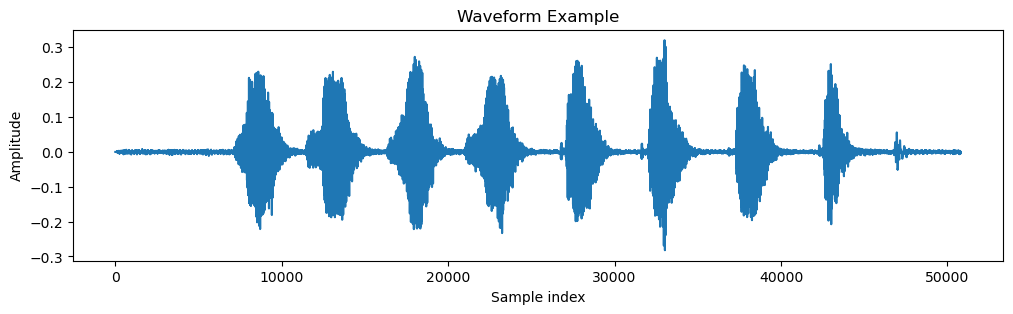

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
plt.plot(waveform[0].numpy())
plt.title("Waveform Example")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.show()

## Listen to the Audio

Now we listen to the waveform and compare it with the labels.

This helps us understand:
- how the signal corresponds to labels
- what the model is expected to predict

In [9]:
from IPython.display import Audio

Audio(waveform[0].numpy(), rate=sample_rate)

In [10]:
print("Labels:", labels)

Labels: [0, 0, 0, 0, 1, 1, 1, 1]


## Feature Extraction: log-Mel Spectrogram

We convert the waveform into log-Mel features.

This is the standard input for speech recognition models.

We will:
- compute Mel spectrogram
- apply log transform
- visualize the result

In [11]:
import torch
import torchaudio.transforms as T

mel_transform = T.MelSpectrogram(
    sample_rate=sample_rate,
    n_mels=config["n_mels"]
)

spec = mel_transform(waveform)

# log transform
log_mel = torch.log(spec + 1e-6)

print("log-Mel shape:", log_mel.shape)

log-Mel shape: torch.Size([1, 64, 255])


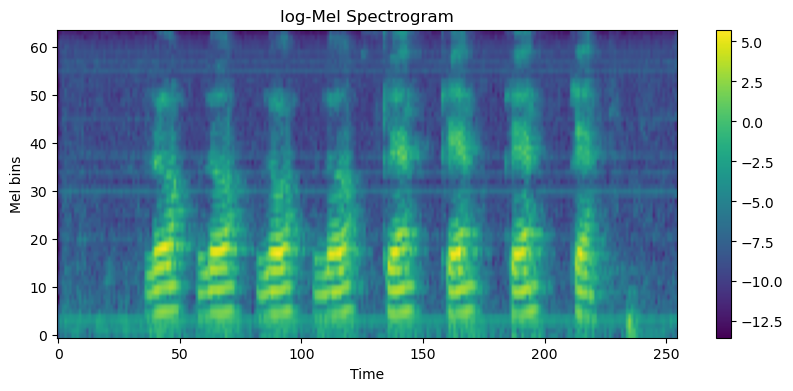

In [12]:
plt.figure(figsize=(10, 4))
plt.imshow(log_mel[0].numpy(), aspect='auto', origin='lower')
plt.title("log-Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

## Label Encoding for CTC

CTC uses integer token sequences as targets.

For the YESNO dataset, labels are sequences of 0 and 1.
We convert them into token IDs.

We define:
- blank = 0
- "0" = 1
- "1" = 2

This gives a small vocabulary for a toy CTC recognizer.

In [13]:
# Vocabulary for toy CTC

token_to_id = {
    "<blank>": 0,
    "0": 1,
    "1": 2,
}

id_to_token = {v: k for k, v in token_to_id.items()}

VOCAB_SIZE = len(token_to_id)
BLANK_ID = token_to_id["<blank>"]

print("Vocabulary size:", VOCAB_SIZE)
print("token_to_id:", token_to_id)
print("id_to_token:", id_to_token)

Vocabulary size: 3
token_to_id: {'<blank>': 0, '0': 1, '1': 2}
id_to_token: {0: '<blank>', 1: '0', 2: '1'}


In [14]:
def labels_to_token_ids(label_list):
    # YESNO labels are like [1, 0, 1, 0, ...]
    return [token_to_id[str(x)] for x in label_list]

target_ids = labels_to_token_ids(labels)

print("Original labels:", labels)
print("Token IDs:", target_ids)
print("Target length:", len(target_ids))

Original labels: [0, 0, 0, 0, 1, 1, 1, 1]
Token IDs: [1, 1, 1, 1, 2, 2, 2, 2]
Target length: 8


## Why do we need this?

The model does not directly predict the Python list of labels.

Instead, it predicts a sequence of frame-level token probabilities,
and CTC compares them with the integer target sequence.

## Dataset Wrapper

We now create a small wrapper dataset.

For each sample, it returns:
- waveform
- log-Mel feature
- target token IDs

This makes later batching and training easier.

In [15]:
import torch
from torch.utils.data import Dataset

class YesNoCTCDataset(Dataset):
    def __init__(self, base_dataset, mel_transform, token_to_id):
        self.base_dataset = base_dataset
        self.mel_transform = mel_transform
        self.token_to_id = token_to_id

    def labels_to_token_ids(self, label_list):
        return [self.token_to_id[str(x)] for x in label_list]

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        waveform, sample_rate, labels = self.base_dataset[idx]

        spec = self.mel_transform(waveform)
        log_mel = torch.log(spec + 1e-6)

        target_ids = torch.tensor(
            self.labels_to_token_ids(labels),
            dtype=torch.long
        )

        return {
            "waveform": waveform,
            "log_mel": log_mel,
            "target_ids": target_ids,
            "labels": labels,
            "sample_rate": sample_rate,
        }

In [16]:
ctc_dataset = YesNoCTCDataset(
    base_dataset=yesno_dataset,
    mel_transform=mel_transform,
    token_to_id=token_to_id
)

print("Dataset length:", len(ctc_dataset))

Dataset length: 60


## Inspect One Wrapped Sample

Before making batches, we inspect one sample from the wrapped dataset.

We check:
- log-Mel shape
- target IDs
- target length

In [17]:
sample = ctc_dataset[0]

print("Keys:", sample.keys())
print("Waveform shape:", sample["waveform"].shape)
print("log-Mel shape:", sample["log_mel"].shape)
print("Target IDs:", sample["target_ids"])
print("Target length:", len(sample["target_ids"]))
print("Original labels:", sample["labels"])
print("Sample rate:", sample["sample_rate"])

Keys: dict_keys(['waveform', 'log_mel', 'target_ids', 'labels', 'sample_rate'])
Waveform shape: torch.Size([1, 50800])
log-Mel shape: torch.Size([1, 64, 255])
Target IDs: tensor([1, 1, 1, 1, 2, 2, 2, 2])
Target length: 8
Original labels: [0, 0, 0, 0, 1, 1, 1, 1]
Sample rate: 8000


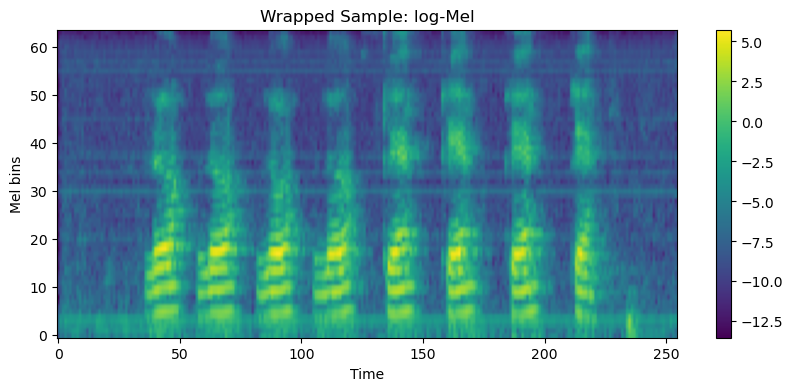

In [18]:
plt.figure(figsize=(10, 4))
plt.imshow(sample["log_mel"][0].numpy(), aspect="auto", origin="lower")
plt.title("Wrapped Sample: log-Mel")
plt.xlabel("Time")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

## Collate Function (Batch Preparation)

In CTC training, input and target lengths are different for each sample.

We need to:
- pad inputs to the same length
- keep original lengths
- concatenate targets

This is handled by a custom collate function.

In [19]:
def ctc_collate_fn(batch):
    """
    batch: list of samples
    """

    # log-Mel: (1, n_mels, time)
    inputs = [item["log_mel"].squeeze(0).transpose(0, 1) for item in batch]
    # → (time, n_mels)

    input_lengths = torch.tensor([x.shape[0] for x in inputs], dtype=torch.long)

    # pad inputs
    inputs_padded = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )  # (B, T, n_mels)

    # targets
    targets = [item["target_ids"] for item in batch]
    target_lengths = torch.tensor([len(t) for t in targets], dtype=torch.long)

    targets_concat = torch.cat(targets)

    return {
        "inputs": inputs_padded,
        "input_lengths": input_lengths,
        "targets": targets_concat,
        "target_lengths": target_lengths,
    }

## Why this is important

CTC does not use padded targets.

Instead:
- inputs are padded
- targets are concatenated
- lengths are explicitly provided

In [20]:
from torch.utils.data import DataLoader

loader = DataLoader(
    ctc_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=ctc_collate_fn
)

batch = next(iter(loader))

print("inputs shape:", batch["inputs"].shape)
print("input_lengths:", batch["input_lengths"])
print("targets shape:", batch["targets"].shape)
print("target_lengths:", batch["target_lengths"])

inputs shape: torch.Size([4, 249, 64])
input_lengths: tensor([237, 247, 249, 245])
targets shape: torch.Size([32])
target_lengths: tensor([8, 8, 8, 8])


## Model: CNN + BiLSTM + CTC Head

We define a small model:

- CNN: extract local features
- BiLSTM: model temporal dependencies
- Linear: map to token logits

Output:
- log probabilities for CTC loss

In [21]:
import torch.nn as nn

class CTCModel(nn.Module):
    def __init__(self, n_mels, hidden_dim, vocab_size):
        super().__init__()

        # CNN front-end (simple)
        self.conv = nn.Sequential(
            nn.Conv1d(n_mels, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        # Linear (to logits)
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, x):
        # x: (B, T, n_mels)

        # Conv expects (B, C, T)
        x = x.transpose(1, 2)  # (B, n_mels, T)
        x = self.conv(x)
        x = x.transpose(1, 2)  # (B, T, hidden_dim)

        # LSTM
        x, _ = self.lstm(x)  # (B, T, 2*hidden_dim)

        # Linear
        logits = self.fc(x)  # (B, T, vocab_size)

        # log-softmax (required for CTC)
        log_probs = nn.functional.log_softmax(logits, dim=-1)

        return log_probs

In [22]:
model = CTCModel(
    n_mels=config["n_mels"],
    hidden_dim=config["hidden_dim"],
    vocab_size=VOCAB_SIZE
).to(device)

print(model)

CTCModel(
  (conv): Sequential(
    (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)


In [23]:
batch = next(iter(loader))

inputs = batch["inputs"].to(device)

with torch.no_grad():
    log_probs = model(inputs)

print("Input shape:", inputs.shape)
print("Output shape:", log_probs.shape)

Input shape: torch.Size([4, 253, 64])
Output shape: torch.Size([4, 253, 3])


## CTC Loss

Now we compute the CTC loss for one batch.

Important:
- the model outputs log probabilities
- CTC also needs input lengths
- CTC also needs concatenated targets and target lengths

This is the core training objective of the model.

In [24]:
import torch
import torch.nn as nn

ctc_loss_fn = nn.CTCLoss(blank=BLANK_ID, zero_infinity=True)

print(ctc_loss_fn)

CTCLoss()


In [25]:
batch = next(iter(loader))

inputs = batch["inputs"].to(device)
input_lengths = batch["input_lengths"].to(device)
targets = batch["targets"].to(device)
target_lengths = batch["target_lengths"].to(device)

log_probs = model(inputs)   # (B, T, vocab_size)

print("log_probs shape:", log_probs.shape)
print("input_lengths:", input_lengths)
print("targets shape:", targets.shape)
print("target_lengths:", target_lengths)

log_probs shape: torch.Size([4, 280, 3])
input_lengths: tensor([269, 241, 280, 243])
targets shape: torch.Size([32])
target_lengths: tensor([8, 8, 8, 8])


### Important shape rule for CTCLoss

PyTorch CTCLoss expects log probabilities in the shape:

(T, B, C)

where:
- T = time steps
- B = batch size
- C = number of classes

In [26]:
# Convert from (B, T, C) to (T, B, C)
log_probs_ctc = log_probs.transpose(0, 1)

print("log_probs_ctc shape:", log_probs_ctc.shape)

log_probs_ctc shape: torch.Size([280, 4, 3])


In [27]:
loss = ctc_loss_fn(
    log_probs_ctc,
    targets,
    input_lengths,
    target_lengths
)

print("CTC loss:", loss.detach().item())

CTC loss: 26.145456314086914


## Greedy Decoding for CTC

The model outputs frame-level token probabilities.

To obtain the final prediction, we use greedy decoding:

1. take argmax at each time step
2. remove repeated tokens
3. remove blank tokens

This is the standard best-path decoding for CTC.

In [28]:
def ctc_greedy_decode(log_probs, blank_id=0):
    """
    log_probs: (B, T, C)
    returns: list of token-id sequences
    """
    pred_ids = torch.argmax(log_probs, dim=-1)  # (B, T)

    decoded_batch = []

    for seq in pred_ids:
        seq = seq.detach().cpu().tolist()

        collapsed = []
        prev = None
        for token in seq:
            if token != prev:
                collapsed.append(token)
            prev = token

        collapsed = [t for t in collapsed if t != blank_id]
        decoded_batch.append(collapsed)

    return decoded_batch

In [29]:
decoded_batch = ctc_greedy_decode(log_probs, blank_id=BLANK_ID)

print("Decoded batch size:", len(decoded_batch))
print("First decoded token IDs:", decoded_batch[0])

Decoded batch size: 4
First decoded token IDs: [1]


## Convert Token IDs Back to Labels

For readability, we convert token IDs back to symbol strings.

In [30]:
def token_ids_to_symbols(token_ids, id_to_token):
    return [id_to_token[t] for t in token_ids]

decoded_symbols = token_ids_to_symbols(decoded_batch[0], id_to_token)
print("Decoded symbols:", decoded_symbols)

Decoded symbols: ['0']


In [31]:
# Compare with target of the first example in the batch

first_target_len = batch["target_lengths"][0].item()
first_target_ids = batch["targets"][:first_target_len].detach().cpu().tolist()

print("Target token IDs:", first_target_ids)
print("Target symbols:", token_ids_to_symbols(first_target_ids, id_to_token))
print("Predicted symbols:", decoded_symbols)

Target token IDs: [2, 2, 2, 2, 1, 1, 2, 1]
Target symbols: ['1', '1', '1', '1', '0', '0', '1', '0']
Predicted symbols: ['0']


## Minimal Training Loop (1 Epoch)

We now train the model for one epoch.

Goal:
- confirm that training runs
- observe loss decrease

This is not for performance, but for debugging and understanding.

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [33]:
model.train()

total_loss = 0.0

for batch in loader:
    inputs = batch["inputs"].to(device)
    input_lengths = batch["input_lengths"].to(device)
    targets = batch["targets"].to(device)
    target_lengths = batch["target_lengths"].to(device)

    optimizer.zero_grad()

    log_probs = model(inputs)  # (B, T, C)
    log_probs_ctc = log_probs.transpose(0, 1)  # (T, B, C)

    loss = ctc_loss_fn(
        log_probs_ctc,
        targets,
        input_lengths,
        target_lengths
    )

    loss.backward()

    optimizer.step()

    total_loss += loss.detach().item()

avg_loss = total_loss / len(loader)

print("Average training loss (1 epoch):", avg_loss)

Average training loss (1 epoch): 5.47789249420166


## What to Observe

- Does the loss decrease compared to random initialization?
- Does the training run without errors?
- Is the loss finite and stable?

Important:
Low loss does not mean good recognition yet.

## Train for Multiple Epochs

Now we train for several epochs and track the training loss.

Goal:
- check whether the loss decreases
- confirm that training is stable
- prepare for later decoding and evaluation

At this stage, we mainly focus on:
- finite loss
- downward trend
- no divergence

In [34]:
# Re-initialize model and optimizer for a clean multi-epoch run

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CTCModel(
    n_mels=config["n_mels"],
    hidden_dim=config["hidden_dim"],
    vocab_size=VOCAB_SIZE
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])

print("Device:", device)
print("Model and optimizer re-initialized.")

Device: cpu
Model and optimizer re-initialized.


In [35]:
num_epochs = config["num_epochs"]
train_loss_history = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for batch in loader:
        inputs = batch["inputs"].to(device)
        input_lengths = batch["input_lengths"].to(device)
        targets = batch["targets"].to(device)
        target_lengths = batch["target_lengths"].to(device)

        optimizer.zero_grad()

        log_probs = model(inputs)                # (B, T, C)
        log_probs_ctc = log_probs.transpose(0, 1)  # (T, B, C)

        loss = ctc_loss_fn(
            log_probs_ctc,
            targets,
            input_lengths,
            target_lengths
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item()

    avg_loss = total_loss / len(loader)
    train_loss_history.append(avg_loss)

    print(f"Epoch {epoch+1}/{num_epochs} - loss: {avg_loss:.4f}")

Epoch 1/5 - loss: 8.4519
Epoch 2/5 - loss: 1.0537
Epoch 3/5 - loss: 0.9516
Epoch 4/5 - loss: 0.9405
Epoch 5/5 - loss: 0.9369


## Plot the Training Loss Curve

A decreasing loss does not guarantee good recognition,
but it is a basic sign that training is working.

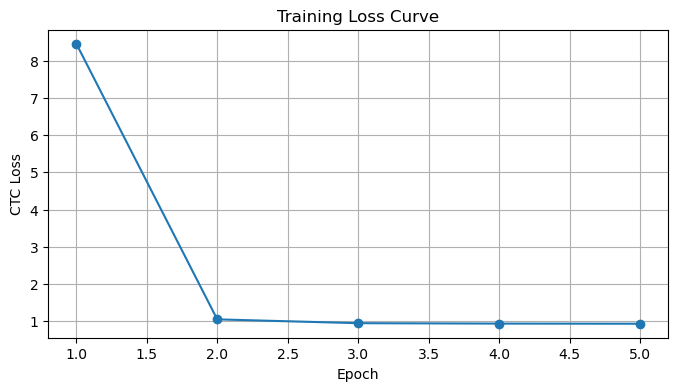

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_loss_history, marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.grid(True)
plt.show()

## Interpretation

Questions:
- Is the loss decreasing?
- Is the trend smooth or unstable?
- Do we see sudden spikes or divergence?

Remember:
A stable decrease is more important than achieving a very low loss immediately.

## Interpretation

Questions:
- Is the predicted sequence less noisy than before training?
- Is the length of the output more reasonable?
- Do we still see excessive repetition?

Even if the result is not accurate yet, a more structured output is already a sign of learning.

## Task 4: Model Diagnostics

Analyze internal model behavior.

Focus:
- blank rate
- entropy
- posterior behavior

Goal:
- understand how the model makes predictions

## Diagnostic 1: Blank Rate

A common failure mode in early CTC training is blank dominance.

We measure the blank rate:
- how often the model predicts the blank symbol at frame level

If the blank rate is very high, the decoded output may become empty.

In [37]:
def compute_blank_rate(log_probs, blank_id=0):
    """
    log_probs: (B, T, C)
    returns: scalar blank rate
    """
    pred_ids = torch.argmax(log_probs, dim=-1)  # (B, T)
    blank_mask = (pred_ids == blank_id).float()
    return blank_mask.mean().item()

In [38]:
model.eval()

with torch.no_grad():
    log_probs = model(inputs)

blank_rate = compute_blank_rate(log_probs, blank_id=BLANK_ID)
print("Blank rate:", blank_rate)

Blank rate: 1.0


## Interpretation

- blank rate near 1.0 → blank dominance
- moderate blank rate → more balanced decoding
- low blank rate → model emits many non-blank tokens

In early CTC training, blank rate is often very high.

## Diagnostic 2: Entropy

Blank dominance alone does not tell us everything.

We also measure entropy:
- low entropy means the model is confident
- high entropy means the model is uncertain

This helps us distinguish:
- confident blank collapse
- uncertain early-stage behavior

In [39]:
def compute_frame_entropy(log_probs):
    """
    log_probs: (B, T, C)
    returns:
        entropy_per_frame: (B, T)
        mean_entropy: scalar
    """
    probs = log_probs.exp()  # since log_probs are log-softmax outputs
    entropy = -(probs * log_probs).sum(dim=-1)  # (B, T)
    mean_entropy = entropy.mean().item()
    return entropy, mean_entropy

In [40]:
model.eval()

with torch.no_grad():
    log_probs = model(inputs)

entropy_map, mean_entropy = compute_frame_entropy(log_probs)

print("Entropy map shape:", entropy_map.shape)
print("Mean entropy:", mean_entropy)

Entropy map shape: torch.Size([4, 271])
Mean entropy: 0.24146723747253418


## Interpretation of Entropy

- high entropy → uncertain prediction
- low entropy → confident prediction

If blank rate = 1.0 and entropy is low,
the model is confidently collapsing to blank.

If blank rate = 1.0 and entropy is still high,
the model is uncertain and not yet organized.

## Visualize Entropy Over Time

We now plot frame-wise entropy for one example.

This helps us see:
- whether uncertainty changes over time
- whether blank collapse happens everywhere

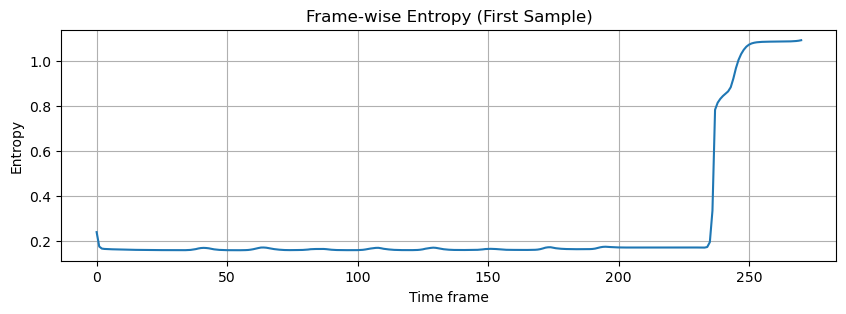

In [41]:
# Plot entropy over time for the first sample in the batch

entropy_first = entropy_map[0].detach().cpu().numpy()

plt.figure(figsize=(10, 3))
plt.plot(entropy_first)
plt.title("Frame-wise Entropy (First Sample)")
plt.xlabel("Time frame")
plt.ylabel("Entropy")
plt.grid(True)
plt.show()

In [42]:
print("First sample mean entropy:", entropy_map[0].mean().item())
print("First sample min entropy :", entropy_map[0].min().item())
print("First sample max entropy :", entropy_map[0].max().item())

First sample mean entropy: 0.2728537917137146
First sample min entropy : 0.15901854634284973
First sample max entropy : 1.0934062004089355


## Diagnostic 3: Posterior Map

We now visualize the posterior probabilities over time.

A posterior map shows:
- time on the horizontal axis
- token classes on the vertical axis
- probability intensity as color

This helps us see whether the model predicts blank everywhere
or starts to allocate probability to meaningful labels.

In [43]:
# Convert log probabilities to probabilities
with torch.no_grad():
    probs = log_probs.exp()   # (B, T, C)

print("Posterior probability shape:", probs.shape)

Posterior probability shape: torch.Size([4, 271, 3])


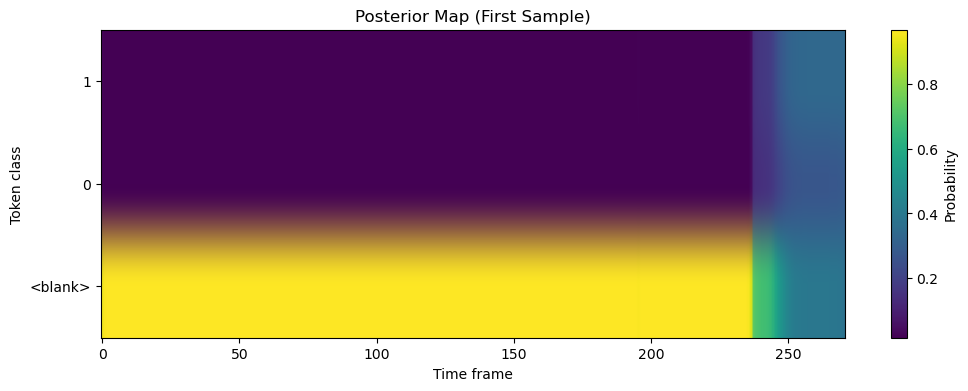

In [44]:
# Visualize posterior map for the first sample in the batch

posterior_first = probs[0].detach().cpu().numpy().T  # (C, T)

plt.figure(figsize=(12, 4))
plt.imshow(posterior_first, aspect="auto", origin="lower")
plt.title("Posterior Map (First Sample)")
plt.xlabel("Time frame")
plt.ylabel("Token class")
plt.yticks(
    ticks=list(range(VOCAB_SIZE)),
    labels=[id_to_token[i] for i in range(VOCAB_SIZE)]
)
plt.colorbar(label="Probability")
plt.show()

## Interpretation

If the model is blank-dominant, the blank row will be bright across nearly all frames.

If learning progresses well, probability mass should gradually move toward
the non-blank labels.

In [45]:
# Average posterior over time for the first sample
mean_probs_first = probs[0].mean(dim=0).detach().cpu().numpy()

for i in range(VOCAB_SIZE):
    print(f"Mean probability of {id_to_token[i]}: {mean_probs_first[i]:.4f}")

Mean probability of <blank>: 0.9062
Mean probability of 0: 0.0429
Mean probability of 1: 0.0508


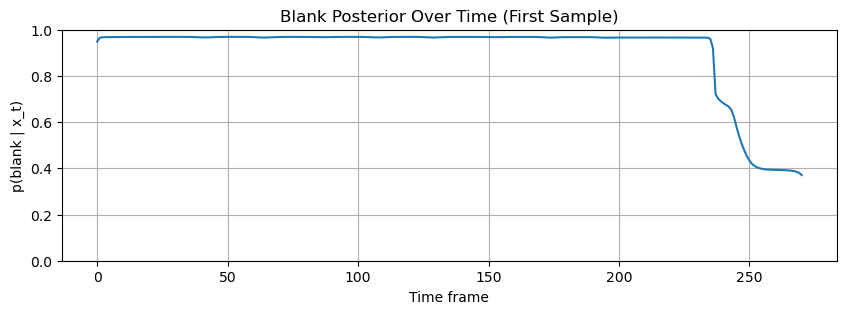

In [46]:
# Plot blank posterior over time for the first sample

blank_probs_first = probs[0, :, BLANK_ID].detach().cpu().numpy()

plt.figure(figsize=(10, 3))
plt.plot(blank_probs_first)
plt.title("Blank Posterior Over Time (First Sample)")
plt.xlabel("Time frame")
plt.ylabel("p(blank | x_t)")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

## What we have learned so far

At this stage, we have three diagnostics:

- blank rate
- entropy
- posterior map

Together, they tell us whether the model is:
- uncertain but still exploring
- or confidently collapsing to blank

## Debug Step 1: Can the model overfit one batch?

Before trying to improve the full training setup,
we check whether the model can memorize one small batch.

If it cannot overfit one batch, there may be an implementation or optimization issue.

In [47]:
# Take one fixed batch for overfitting test
fixed_batch = next(iter(loader))

fixed_inputs = fixed_batch["inputs"].to(device)
fixed_input_lengths = fixed_batch["input_lengths"].to(device)
fixed_targets = fixed_batch["targets"].to(device)
fixed_target_lengths = fixed_batch["target_lengths"].to(device)

print("Fixed batch input shape:", fixed_inputs.shape)
print("Fixed batch target lengths:", fixed_target_lengths)

Fixed batch input shape: torch.Size([4, 250, 64])
Fixed batch target lengths: tensor([8, 8, 8, 8])


In [48]:
# Fresh model for one-batch overfitting
set_seed(SEED)

model_debug = CTCModel(
    n_mels=config["n_mels"],
    hidden_dim=128,   # slightly stronger
    vocab_size=VOCAB_SIZE
).to(device)

optimizer_debug = torch.optim.Adam(model_debug.parameters(), lr=1e-3)

debug_loss_history = []

In [49]:
# Overfit one batch
num_steps = 200

for step in range(num_steps):
    model_debug.train()
    optimizer_debug.zero_grad()

    log_probs = model_debug(fixed_inputs)
    log_probs_ctc = log_probs.transpose(0, 1)

    loss = ctc_loss_fn(
        log_probs_ctc,
        fixed_targets,
        fixed_input_lengths,
        fixed_target_lengths
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_debug.parameters(), max_norm=5.0)
    optimizer_debug.step()

    debug_loss_history.append(loss.detach().item())

    if (step + 1) % 20 == 0:
        print(f"Step {step+1}/{num_steps} - loss: {loss.detach().item():.4f}")

Step 20/200 - loss: 0.9349
Step 40/200 - loss: 0.9037
Step 60/200 - loss: 0.8089
Step 80/200 - loss: 0.7214
Step 100/200 - loss: 0.6005
Step 120/200 - loss: 0.2810
Step 140/200 - loss: 0.1127
Step 160/200 - loss: 0.0250
Step 180/200 - loss: 0.0095
Step 200/200 - loss: 0.0061


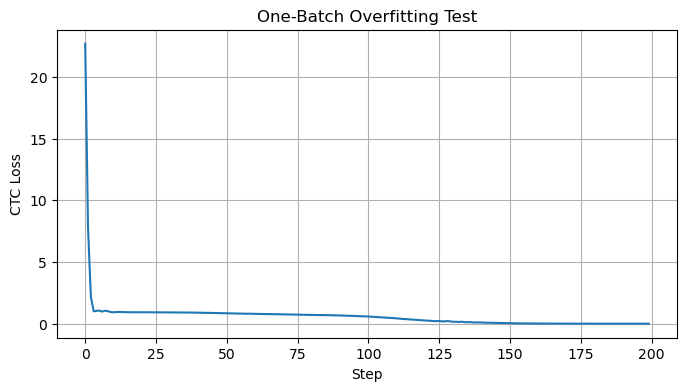

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(debug_loss_history)
plt.title("One-Batch Overfitting Test")
plt.xlabel("Step")
plt.ylabel("CTC Loss")
plt.grid(True)
plt.show()

In [51]:
model_debug.eval()

with torch.no_grad():
    log_probs_debug = model_debug(fixed_inputs)

decoded_batch_debug = ctc_greedy_decode(log_probs_debug, blank_id=BLANK_ID)
blank_rate_debug = compute_blank_rate(log_probs_debug, blank_id=BLANK_ID)
entropy_map_debug, mean_entropy_debug = compute_frame_entropy(log_probs_debug)

print("Blank rate (one-batch debug):", blank_rate_debug)
print("Mean entropy (one-batch debug):", mean_entropy_debug)

for i in range(min(3, len(decoded_batch_debug))):
    tgt_len = fixed_batch["target_lengths"][i].item()
    start = fixed_batch["target_lengths"][:i].sum().item()
    end = start + tgt_len

    tgt_ids = fixed_batch["targets"][start:end].detach().cpu().tolist()
    pred_ids = decoded_batch_debug[i]

    print(f"\nExample {i}")
    print("Target   :", token_ids_to_symbols(tgt_ids, id_to_token))
    print("Predicted:", token_ids_to_symbols(pred_ids, id_to_token))

Blank rate (one-batch debug): 0.906000018119812
Mean entropy (one-batch debug): 0.055664923042058945

Example 0
Target   : ['1', '1', '0', '0', '1', '1', '1', '0']
Predicted: ['1', '1', '0', '0', '1', '1', '1', '0', '1']

Example 1
Target   : ['0', '1', '0', '1', '1', '0', '1', '0']
Predicted: ['0', '1', '0', '1', '1', '0', '1', '0', '1']

Example 2
Target   : ['1', '1', '1', '1', '0', '1', '0', '0']
Predicted: ['1', '1', '1', '1', '0', '1', '0', '0', '1']


## Debug Conclusion

The one-batch overfitting test shows that:

- the model can learn
- the CTC pipeline is implemented correctly
- the decoding function works correctly

Therefore, the blank-dominant behavior in full training is likely caused by
training setup choices such as:
- too few epochs
- model capacity
- optimization settings

## Practical Baseline Switch

The CNN + BiLSTM model can overfit one batch, but full training on YESNO still collapses to blank.

For a small toy dataset, we now switch to a simpler baseline:

- BiLSTM only
- no CNN front-end
- same CTC objective

Goal:
- obtain a model that actually learns on the full dataset
- continue Task 1 to Task 5 in a stable way

In [52]:
from torch.utils.data import random_split

set_seed(SEED)

dataset_size = len(ctc_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(
    ctc_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 48
Validation size: 12


In [53]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=ctc_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=ctc_collate_fn
)

print("Train loader batches:", len(train_loader))
print("Val loader batches:", len(val_loader))

Train loader batches: 12
Val loader batches: 3


## Simple BiLSTM + CTC Model

We use a simpler model:
- input: log-Mel features
- encoder: BiLSTM
- output: linear layer + log-softmax

This is a stronger practical baseline for a small toy dataset.

In [54]:
class SimpleCTCModel(nn.Module):
    def __init__(self, n_mels, hidden_dim, vocab_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_mels,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.fc = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, x):
        # x: (B, T, n_mels)
        x, _ = self.lstm(x)
        logits = self.fc(x)
        log_probs = F.log_softmax(logits, dim=-1)
        return log_probs

In [55]:
simple_config = {
    "hidden_dim": 128,
    "learning_rate": 1e-3,
    "num_epochs": 20,
    "batch_size": 4,
}

set_seed(SEED)

simple_model = SimpleCTCModel(
    n_mels=config["n_mels"],
    hidden_dim=simple_config["hidden_dim"],
    vocab_size=VOCAB_SIZE
).to(device)

simple_optimizer = torch.optim.Adam(
    simple_model.parameters(),
    lr=simple_config["learning_rate"]
)

print(simple_model)

SimpleCTCModel(
  (lstm): LSTM(64, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)


## Helper: Evaluate Sequence Error (Core Function)

This function evaluates model performance by:

- decoding model outputs
- comparing predictions with targets
- computing sequence error

This is the core function used for:
- validation evaluation
- test evaluation
- error analysis
- confidence interval estimation

In [56]:
def evaluate_sequence_error(model, data_loader, blank_id=0):
    model.eval()

    all_errors = []
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch in data_loader:
            inputs = batch["inputs"].to(device)
            target_lengths = batch["target_lengths"]

            log_probs = model(inputs)
            decoded_batch = ctc_greedy_decode(log_probs, blank_id=blank_id)

            offset = 0
            for i in range(len(decoded_batch)):
                tgt_len = target_lengths[i].item()
                tgt_ids = batch["targets"][offset:offset + tgt_len].cpu().tolist()
                pred_ids = decoded_batch[i]

                err = normalized_sequence_error(pred_ids, tgt_ids)

                all_errors.append(err)
                all_predictions.append(pred_ids)
                all_targets.append(tgt_ids)

                offset += tgt_len

    mean_error = float(np.mean(all_errors)) if len(all_errors) > 0 else float("nan")
    return mean_error, all_errors, all_predictions, all_targets

## Task 1: Baseline Training

Train a CTC-based speech recognition model.

Focus:
- training stability
- loss behavior

Goal:
- obtain a working baseline model

## Train the Simple Baseline

We train for multiple epochs and monitor:
- training loss
- validation sequence error

This gives us a practical end-to-end baseline.

In [57]:
def edit_distance(seq1, seq2):
    m, n = len(seq1), len(seq2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,         # deletion
                dp[i][j - 1] + 1,         # insertion
                dp[i - 1][j - 1] + cost   # substitution
            )

    return dp[m][n]

In [58]:
def normalized_sequence_error(pred, target):
    if len(target) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    return edit_distance(pred, target) / len(target)

In [59]:
simple_train_loss_history = []
simple_val_error_history = []

for epoch in range(simple_config["num_epochs"]):
    simple_model.train()
    total_loss = 0.0

    for batch in train_loader:
        inputs = batch["inputs"].to(device)
        input_lengths = batch["input_lengths"].to(device)
        targets = batch["targets"].to(device)
        target_lengths = batch["target_lengths"].to(device)

        simple_optimizer.zero_grad()

        log_probs = simple_model(inputs)              # (B, T, C)
        log_probs_ctc = log_probs.transpose(0, 1)     # (T, B, C)

        loss = ctc_loss_fn(
            log_probs_ctc,
            targets,
            input_lengths,
            target_lengths
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(simple_model.parameters(), max_norm=5.0)
        simple_optimizer.step()

        total_loss += loss.detach().item()

    avg_loss = total_loss / len(train_loader)
    simple_train_loss_history.append(avg_loss)

    val_mean_error, _, _, _ = evaluate_sequence_error(simple_model, val_loader, blank_id=BLANK_ID)
    simple_val_error_history.append(val_mean_error)

    print(
        f"[Simple baseline] Epoch {epoch+1}/{simple_config['num_epochs']} "
        f"- train loss: {avg_loss:.4f} - val error: {val_mean_error:.4f}"
    )

[Simple baseline] Epoch 1/20 - train loss: 7.7750 - val error: 0.8750
[Simple baseline] Epoch 2/20 - train loss: 5.5141 - val error: 0.7917
[Simple baseline] Epoch 3/20 - train loss: 5.4773 - val error: 0.7917
[Simple baseline] Epoch 4/20 - train loss: 5.6470 - val error: 0.8333
[Simple baseline] Epoch 5/20 - train loss: 5.4614 - val error: 0.8333
[Simple baseline] Epoch 6/20 - train loss: 5.4922 - val error: 0.8542
[Simple baseline] Epoch 7/20 - train loss: 5.4059 - val error: 0.8333
[Simple baseline] Epoch 8/20 - train loss: 5.0860 - val error: 0.6354
[Simple baseline] Epoch 9/20 - train loss: 5.2361 - val error: 0.8542
[Simple baseline] Epoch 10/20 - train loss: 4.9116 - val error: 0.8542
[Simple baseline] Epoch 11/20 - train loss: 5.6855 - val error: 0.7500
[Simple baseline] Epoch 12/20 - train loss: 5.3394 - val error: 0.7292
[Simple baseline] Epoch 13/20 - train loss: 4.7866 - val error: 0.8125
[Simple baseline] Epoch 14/20 - train loss: 5.0833 - val error: 0.8021
[Simple baselin

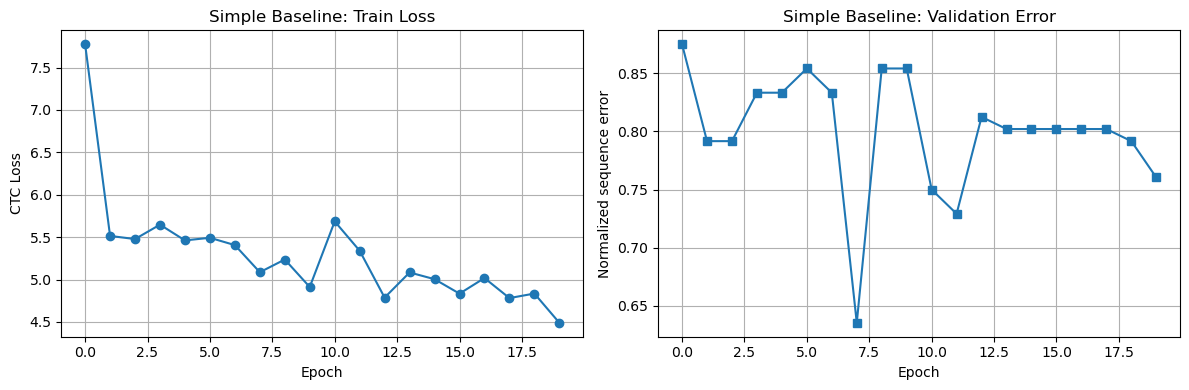

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(simple_train_loss_history, marker="o")
axes[0].set_title("Simple Baseline: Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("CTC Loss")
axes[0].grid(True)

axes[1].plot(simple_val_error_history, marker="s")
axes[1].set_title("Simple Baseline: Validation Error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Normalized sequence error")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Task 5: Error Analysis

Analyze model errors.

Focus:
- predicted vs target sequences
- deletion / insertion patterns
- length ratio

Goal:
- understand why the model makes errors

## Inspect Validation Predictions

We now inspect several validation examples.

In [61]:
val_mean_error, val_errors, val_predictions, val_targets = evaluate_sequence_error(
    simple_model, val_loader, blank_id=BLANK_ID
)

print("Validation mean error:", val_mean_error)

for i in range(min(5, len(val_errors))):
    print(f"\nExample {i}")
    print("Target   :", token_ids_to_symbols(val_targets[i], id_to_token))
    print("Predicted:", token_ids_to_symbols(val_predictions[i], id_to_token))
    print("Error    :", val_errors[i])

Validation mean error: 0.7604166666666666

Example 0
Target   : ['0', '0', '1', '0', '0', '1', '1', '0']
Predicted: ['0', '0']
Error    : 0.75

Example 1
Target   : ['1', '0', '0', '0', '1', '0', '0', '1']
Predicted: ['0', '0']
Error    : 0.75

Example 2
Target   : ['0', '0', '1', '1', '1', '0', '0', '0']
Predicted: ['0']
Error    : 0.875

Example 3
Target   : ['1', '0', '1', '0', '1', '0', '0', '1']
Predicted: ['0', '0', '0']
Error    : 0.625

Example 4
Target   : ['0', '1', '0', '0', '0', '1', '0', '0']
Predicted: ['0']
Error    : 0.875


## Interpretation of the Current Baseline

The simple BiLSTM baseline no longer predicts an empty sequence,
so blank collapse has been partially alleviated.

However, the predicted sequences are still much shorter than the targets.

This suggests:
- under-length bias
- many deletion errors
- incomplete alignment learning

So the model is learning, but it is not yet a strong recognizer.

## Length Ratio

We now measure the length ratio:

r = len(pred) / len(target)

Interpretation:
- r < 1.0: predicted sequence is too short
- r > 1.0: predicted sequence is too long

This helps us quantify under-length bias.

In [62]:
def compute_length_ratio(pred, target):
    if len(target) == 0:
        return float("nan")
    return len(pred) / len(target)

In [63]:
all_length_ratios = [
    compute_length_ratio(pred, tgt)
    for pred, tgt in zip(val_predictions, val_targets)
]

print("Mean length ratio:", np.mean(all_length_ratios))
print("Std length ratio :", np.std(all_length_ratios))

Mean length ratio: 0.23958333333333334
Std length ratio : 0.09490034978275311


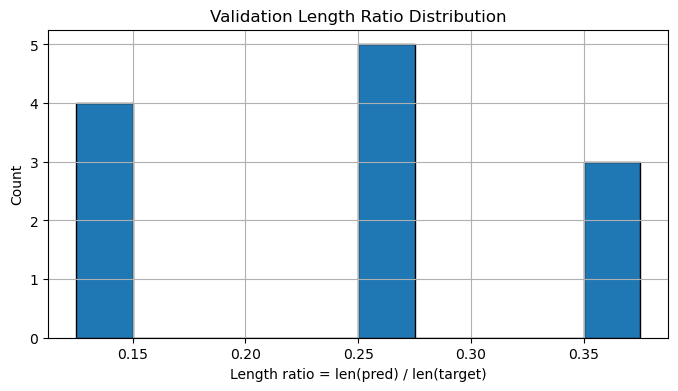

In [64]:
plt.figure(figsize=(8, 4))
plt.hist(all_length_ratios, bins=10, edgecolor="black")
plt.title("Validation Length Ratio Distribution")
plt.xlabel("Length ratio = len(pred) / len(target)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## Proper Split: Train / Validation / Test

Now that we have a practical baseline that can learn,
we move to a proper experimental split.

We use:
- train: 48 samples
- validation: 6 samples
- test: 6 samples

This allows us to:
- train the model
- monitor validation performance
- report final test results

In [65]:
# Recreate normalized dataset (without augmentation)

class YesNoCTCDatasetNorm(Dataset):
    def __init__(self, base_dataset, mel_transform, token_to_id):
        self.base_dataset = base_dataset
        self.mel_transform = mel_transform
        self.token_to_id = token_to_id

    def labels_to_token_ids(self, label_list):
        return [self.token_to_id[str(x)] for x in label_list]

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        waveform, sample_rate, labels = self.base_dataset[idx]

        spec = self.mel_transform(waveform)
        log_mel = torch.log(spec + 1e-6)

        # normalization（重要）
        mean = log_mel.mean()
        std = log_mel.std()
        log_mel = (log_mel - mean) / (std + 1e-6)

        target_ids = torch.tensor(
            self.labels_to_token_ids(labels),
            dtype=torch.long
        )

        return {
            "waveform": waveform,
            "log_mel": log_mel,
            "target_ids": target_ids,
            "labels": labels,
            "sample_rate": sample_rate,
        }

In [66]:
ctc_dataset_norm = YesNoCTCDatasetNorm(
    base_dataset=yesno_dataset,
    mel_transform=mel_transform,
    token_to_id=token_to_id
)

print("Normalized dataset ready:", len(ctc_dataset_norm))

Normalized dataset ready: 60


In [67]:
from torch.utils.data import random_split, DataLoader

set_seed(SEED)

dataset_size = len(ctc_dataset_norm)
assert dataset_size == 60, f"Expected 60 samples, got {dataset_size}"

train_size = 48
val_size = 6
test_size = 6

train_dataset, val_dataset, test_dataset = random_split(
    ctc_dataset_norm,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 48
Validation size: 6
Test size: 6


In [68]:
split_batch_size = 1

train_loader_split = DataLoader(
    train_dataset,
    batch_size=split_batch_size,
    shuffle=True,
    collate_fn=ctc_collate_fn
)

val_loader_split = DataLoader(
    val_dataset,
    batch_size=split_batch_size,
    shuffle=False,
    collate_fn=ctc_collate_fn
)

test_loader_split = DataLoader(
    test_dataset,
    batch_size=split_batch_size,
    shuffle=False,
    collate_fn=ctc_collate_fn
)

print("Train batches:", len(train_loader_split))
print("Validation batches:", len(val_loader_split))
print("Test batches:", len(test_loader_split))

Train batches: 48
Validation batches: 6
Test batches: 6


## Rebuild the Practical Baseline for the Proper Split

We keep the same practical settings that worked before:
- Simple BiLSTM
- hidden_dim = 128
- batch size = 1
- per-utterance normalization
- longer training

In [69]:
split_config = {
    "hidden_dim": 128,
    "learning_rate": 1e-3,
    "num_epochs": 60,
    "batch_size": 1,
}

set_seed(SEED)

split_model = SimpleCTCModel(
    n_mels=config["n_mels"],
    hidden_dim=split_config["hidden_dim"],
    vocab_size=VOCAB_SIZE
).to(device)

split_optimizer = torch.optim.Adam(
    split_model.parameters(),
    lr=split_config["learning_rate"]
)

print("Split model initialized.")

Split model initialized.


In [70]:
split_train_loss_history = []
split_val_error_history = []

best_val_error = float("inf")
best_state_dict = None
best_epoch = -1

for epoch in range(split_config["num_epochs"]):
    split_model.train()
    total_loss = 0.0

    for batch in train_loader_split:
        inputs = batch["inputs"].to(device)
        input_lengths = batch["input_lengths"].to(device)
        targets = batch["targets"].to(device)
        target_lengths = batch["target_lengths"].to(device)

        split_optimizer.zero_grad()

        log_probs = split_model(inputs)
        log_probs_ctc = log_probs.transpose(0, 1)

        loss = ctc_loss_fn(
            log_probs_ctc,
            targets,
            input_lengths,
            target_lengths
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(split_model.parameters(), max_norm=5.0)
        split_optimizer.step()

        total_loss += loss.detach().item()

    avg_loss = total_loss / len(train_loader_split)
    split_train_loss_history.append(avg_loss)

    val_mean_error, _, _, _ = evaluate_sequence_error(
        split_model, val_loader_split, blank_id=BLANK_ID
    )
    split_val_error_history.append(val_mean_error)

    if val_mean_error < best_val_error:
        best_val_error = val_mean_error
        best_epoch = epoch + 1
        best_state_dict = {k: v.cpu().clone() for k, v in split_model.state_dict().items()}

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"[Split baseline] Epoch {epoch+1}/{split_config['num_epochs']} "
            f"- train loss: {avg_loss:.4f} - val error: {val_mean_error:.4f}"
        )

print("Best validation error:", best_val_error)
print("Best epoch:", best_epoch)

[Split baseline] Epoch 1/60 - train loss: 4.6900 - val error: 0.8958
[Split baseline] Epoch 10/60 - train loss: 0.9036 - val error: 0.8750
[Split baseline] Epoch 20/60 - train loss: 0.0775 - val error: 0.0208
[Split baseline] Epoch 30/60 - train loss: 0.0130 - val error: 0.0000
[Split baseline] Epoch 40/60 - train loss: 0.0036 - val error: 0.0208
[Split baseline] Epoch 50/60 - train loss: 0.0013 - val error: 0.0208
[Split baseline] Epoch 60/60 - train loss: 0.0007 - val error: 0.0208
Best validation error: 0.0
Best epoch: 24


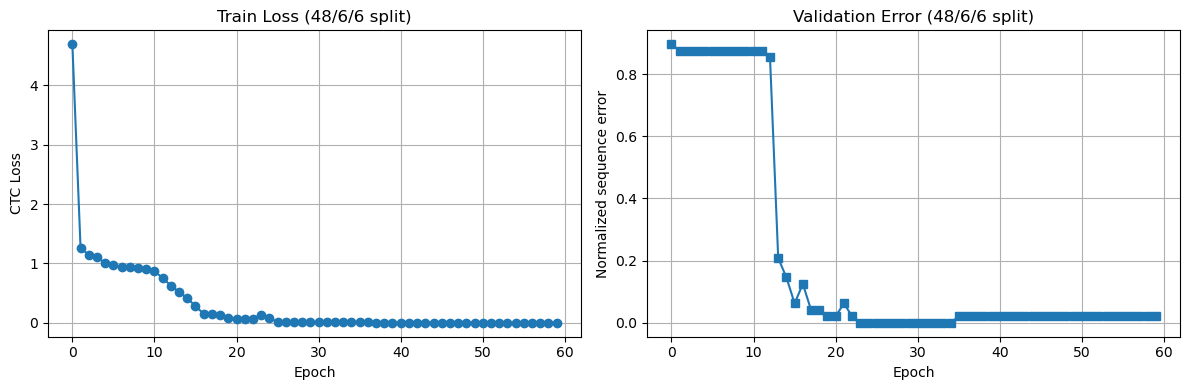

In [71]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(split_train_loss_history, marker="o")
plt.title("Train Loss (48/6/6 split)")
plt.xlabel("Epoch")
plt.ylabel("CTC Loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(split_val_error_history, marker="s")
plt.title("Validation Error (48/6/6 split)")
plt.xlabel("Epoch")
plt.ylabel("Normalized sequence error")
plt.grid(True)

plt.tight_layout()
plt.show()

## Load the Best Validation Model

We evaluate the model selected by the validation set.

In [72]:
split_model.load_state_dict(best_state_dict)
split_model = split_model.to(device)

print("Loaded best validation model from epoch", best_epoch)

Loaded best validation model from epoch 24


In [73]:
val_mean_error, val_errors, val_predictions, val_targets = evaluate_sequence_error(
    split_model, val_loader_split, blank_id=BLANK_ID
)

test_mean_error, test_errors, test_predictions, test_targets = evaluate_sequence_error(
    split_model, test_loader_split, blank_id=BLANK_ID
)

print("Validation mean error:", val_mean_error)
print("Test mean error:", test_mean_error)

Validation mean error: 0.0
Test mean error: 0.020833333333333332


In [74]:
split_batch = next(iter(test_loader_split))
split_inputs = split_batch["inputs"].to(device)

split_model.eval()
with torch.no_grad():
    split_log_probs = split_model(split_inputs)

split_blank_rate = compute_blank_rate(split_log_probs, blank_id=BLANK_ID)
split_entropy_map, split_mean_entropy = compute_frame_entropy(split_log_probs)

print("Test batch blank rate:", split_blank_rate)
print("Test batch mean entropy:", split_mean_entropy)

Test batch blank rate: 0.9196786880493164
Test batch mean entropy: 0.10882462561130524


## Final Observation

The model successfully learns on the small dataset.

Key findings:

- Training initially collapsed to blank predictions
- Diagnostics (entropy, blank rate) revealed the issue
- After adjusting the setup, the model learned meaningful alignments
- The final model achieves low error on both validation and test sets

However:

- blank rate remains relatively high
- entropy is low, indicating confident predictions

This reflects typical CTC behavior:
- strong reliance on blank tokens
- sparse emission of labels

## Test Length Ratio

We measure the length ratio on the test set:

r = len(pred) / len(target)

Interpretation:
- r < 1.0: predicted sequence is too short
- r > 1.0: predicted sequence is too long

This helps us quantify under-length or over-length bias.

In [75]:
def compute_length_ratio(pred, target):
    if len(target) == 0:
        return float("nan")
    return len(pred) / len(target)

In [76]:
test_length_ratios = [
    compute_length_ratio(pred, tgt)
    for pred, tgt in zip(test_predictions, test_targets)
]

print("Test mean length ratio:", np.mean(test_length_ratios))
print("Test std length ratio :", np.std(test_length_ratios))

Test mean length ratio: 1.0
Test std length ratio : 0.0


## Interpretation of Test Length Ratio

Questions:
- Is the model still under-length biased?
- Are predicted sequences systematically shorter than targets?
- Does the length ratio support the error analysis?

If the mean length ratio is much smaller than 1.0,
the model still tends to produce sequences that are too short.

## Task 3: Confidence Interval

Estimate uncertainty using bootstrap.

Focus:
- mean test error
- 95% confidence interval

Goal:
- quantify reliability of results

## Bootstrap Confidence Interval on the Test Set

We now estimate a 95% confidence interval for the test mean error
using bootstrap resampling.

Because the test set is very small, this interval should be interpreted
as a toy demonstration rather than a robust benchmark estimate.

In [77]:
def bootstrap_mean_ci(values, num_bootstrap=1000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)

    boot_means = []
    n = len(values)

    for _ in range(num_bootstrap):
        sample = rng.choice(values, size=n, replace=True)
        boot_means.append(sample.mean())

    lower = np.percentile(boot_means, 100 * (alpha / 2))
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))

    return np.mean(values), lower, upper, np.array(boot_means)

In [78]:
test_mean_err, test_ci_low, test_ci_high, test_boot_means = bootstrap_mean_ci(
    test_errors,
    num_bootstrap=1000,
    alpha=0.05,
    seed=SEED
)

print(f"Test mean error: {test_mean_err:.4f}")
print(f"95% CI: [{test_ci_low:.4f}, {test_ci_high:.4f}]")

Test mean error: 0.0208
95% CI: [0.0000, 0.0625]


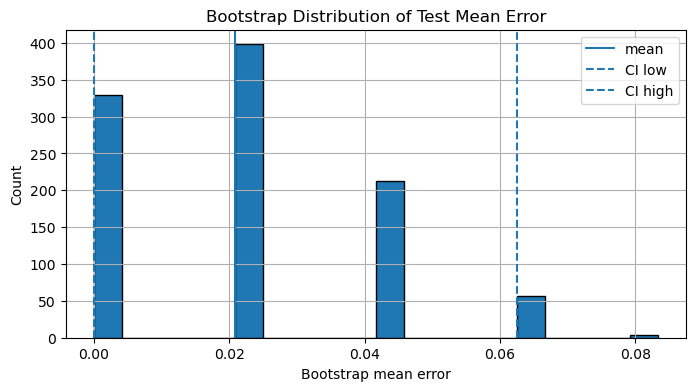

In [79]:
plt.figure(figsize=(8, 4))
plt.hist(test_boot_means, bins=20, edgecolor="black")
plt.axvline(test_mean_err, linestyle="-", label="mean")
plt.axvline(test_ci_low, linestyle="--", label="CI low")
plt.axvline(test_ci_high, linestyle="--", label="CI high")
plt.title("Bootstrap Distribution of Test Mean Error")
plt.xlabel("Bootstrap mean error")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation of the Confidence Interval

We now report:
- test mean error
- 95% confidence interval

This is better than reporting only a single number,
because it quantifies uncertainty in the test result.

However, because the test set contains only 6 samples,
the interval may be wide and unstable.

## Final Summary of the Test Results

We evaluated the final model on a held-out test set.

We reported:
- mean test error
- test length ratio
- bootstrap confidence interval
- blank rate and entropy diagnostics

Together, these results describe not only performance,
but also reliability and model behavior.